# <span style="color:red"> Lecture 20a: Pandas Operations and Data Manipulation </span>

<font size = "4">

We finish up the content from Lecture 17 (and Lecture 18!) we didn't get to last time.

## <span style="color:red"> I. Import Libraries and Read in Files</span>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in the car features dataset
carfeatures = pd.read_csv("data/features.csv")

# Read in the height/weight dataset
df_ht_wt = pd.read_csv("data/SOCR-HeightWeight.csv")

In [3]:
# add "BMI" and "GroupID" columns to df_ht_wt
def pounds_to_kg(wt):
    return wt*0.45359237

def inches_to_meters(ht):
    ht_mm = ht*25.4
    return ht_mm*1e-3

ht_inch = df_ht_wt["Height(Inches)"]
wt_lbs = df_ht_wt["Weight(Pounds)"]

ht_meters = ht_inch.apply(inches_to_meters)
ht_meters.name = "Height(Meters)"
wt_kg = wt_lbs.apply(pounds_to_kg)
wt_kg.name = "Weight(Kilograms)"

BMI = wt_kg/ht_meters**2

df_ht_wt["BMI"] = BMI

In [4]:
# Add random GroupID column 
import numpy as np

# get size of data-set
num_rows, num_cols = df_ht_wt.shape

# randomly generate a number (1,2,3, or 4) for each person in the dataset
group_no = np.random.choice([1, 2, 3, 4], size = num_rows)

df_ht_wt["GroupID"] = group_no


## <span style="color:red"> IV. Filtering Dataframes Based on Logical Expressions </span>

<font size = "4">

(i) Filtering using ```pandas.query()``` 

```python
data.query("logical expression")
```

In [5]:
high_mileagecars = carfeatures.query("mpg >= 25")
print(high_mileagecars)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
18   27.0          4            97         88    2130          14.5  D-1689978
19   26.0          4            97         46    1835          20.5  V-1689989
20   25.0          4           110         87    2672          17.5  P-1690000
22   25.0          4           104         95    2375          17.5  S-1690022
23   26.0          4           121        113    2234          12.5  B-1690033
..    ...        ...           ...        ...     ...           ...        ...
393  27.0          4           140         86    2790          15.6  F-1694103
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
396  28.0          4           120         79    2625          18.6  F-1694136
397  31.0          4           119         82    2720          19.4  C-1694147

[169 rows x 7 columns]


In [6]:
group_4 = df_ht_wt.query("GroupID == 4")
print(group_4)

       Height(Inches)  Weight(Pounds)        BMI  GroupID
0            65.78331        112.9925  18.357624        4
8            67.90265        112.3723  17.135001        4
9            66.78236        120.6672  19.022343        4
11           67.62333        114.1430  17.549085        4
12           68.30248        125.6107  18.930060        4
...               ...             ...        ...      ...
24969        63.61791        115.7477  20.107213        4
24971        67.49720        122.9844  18.979153        4
24974        65.57216        123.7128  20.228979        4
24990        69.97767        125.3672  17.999618        4
24998        67.52918        132.2682  20.392515        4

[6348 rows x 4 columns]


In [7]:
# Use "and" / "or" for logical operations on queries

car_subset = carfeatures.query("(acceleration >= 12) and (acceleration < 18)")
print(car_subset)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
3    16.0          8           304        150    3433          12.0  A-1689813
14   24.0          4           113         95    2372          15.0  T-1689934
15   22.0          6           198         95    2833          15.5  P-1689945
16   18.0          6           199         97    2774          15.5  A-1689956
..    ...        ...           ...        ...     ...           ...        ...
389  22.0          6           232        112    2835          14.7  F-1694059
390  32.0          4           144         96    2665          13.9  T-1694070
391  36.0          4           135         84    2370          13.0  D-1694081
392  27.0          4           151         90    2950          17.3  C-1694092
393  27.0          4           140         86    2790          15.6  F-1694103

[290 rows x 7 columns]


<font size = "4">

(ii) Expressions with colnames + global variables (@)

In [8]:
# You can invoke global variables into the query by using @variablename
# If you don't include @, then Python will try to look for a column with 
# that name.

threshold = 25
high_mileagecars = carfeatures.query("mpg >= @threshold")
print(high_mileagecars)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
18   27.0          4            97         88    2130          14.5  D-1689978
19   26.0          4            97         46    1835          20.5  V-1689989
20   25.0          4           110         87    2672          17.5  P-1690000
22   25.0          4           104         95    2375          17.5  S-1690022
23   26.0          4           121        113    2234          12.5  B-1690033
..    ...        ...           ...        ...     ...           ...        ...
393  27.0          4           140         86    2790          15.6  F-1694103
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
396  28.0          4           120         79    2625          18.6  F-1694136
397  31.0          4           119         82    2720          19.4  C-1694147

[169 rows x 7 columns]


In [9]:
lb = 12
ub = 18

car_subset = carfeatures.query("(acceleration >= @lb) and (acceleration < @ub)")
print(car_subset)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
3    16.0          8           304        150    3433          12.0  A-1689813
14   24.0          4           113         95    2372          15.0  T-1689934
15   22.0          6           198         95    2833          15.5  P-1689945
16   18.0          6           199         97    2774          15.5  A-1689956
..    ...        ...           ...        ...     ...           ...        ...
389  22.0          6           232        112    2835          14.7  F-1694059
390  32.0          4           144         96    2665          13.9  T-1694070
391  36.0          4           135         84    2370          13.0  D-1694081
392  27.0          4           151         90    2950          17.3  C-1694092
393  27.0          4           140         86    2790          15.6  F-1694103

[290 rows x 7 columns]


<font size = "4">

(iii) Handling white space and other characters

Ever wonder why I give folders names like "lecture_18" instead of "lecture 18"? Or name notebooks things like "lecture_18a_pandas_operations.ipynb" instead of "lecture 18a - Pandas operations.ipynb"?

Because handling white spaces on a computer can be annoying in certain situations, as we will see here:

In [11]:
# same data set, but column/variable 0 is "miles per gallon" instead of "mpg"

new_dset = pd.read_csv("data/features-bad-spacing.csv")
print(new_dset)

     miles per gallon  cylinders  displacement horsepower  weight  \
0                18.0          8           307        130    3504   
1                15.0          8           350        165    3693   
2                18.0          8           318        150    3436   
3                16.0          8           304        150    3433   
4                17.0          8           302        140    3449   
..                ...        ...           ...        ...     ...   
393              27.0          4           140         86    2790   
394              44.0          4            97         52    2130   
395              32.0          4           135         84    2295   
396              28.0          4           120         79    2625   
397              31.0          4           119         82    2720   

     acceleration vehicle_id  
0            12.0  C-1689780  
1            11.5  B-1689791  
2            11.0  P-1689802  
3            12.0  A-1689813  
4            10.

In [ ]:
data_threshold_horsepower = new_dset.query("miles per gallon >= 20")

<font size = "4">

Pretty scary looking error message...basically, it doesn't like the space (variable names can't have spaces in Python)

We've seen the double quote (") and the single quote (')

To the left of your 1 key is the backtick/grave accent (`). Need to use this

In [12]:
# next line causes error
# data_threshold_horsepower = new_dset.query("miles per gallon >= 20")

# this next line is fine
data_threshold_horsepower = new_dset.query("`miles per gallon` >= 20")
print(data_threshold_horsepower)

     miles per gallon  cylinders  displacement horsepower  weight  \
14               24.0          4           113         95    2372   
15               22.0          6           198         95    2833   
17               21.0          6           200         85    2587   
18               27.0          4            97         88    2130   
19               26.0          4            97         46    1835   
..                ...        ...           ...        ...     ...   
393              27.0          4           140         86    2790   
394              44.0          4            97         52    2130   
395              32.0          4           135         84    2295   
396              28.0          4           120         79    2625   
397              31.0          4           119         82    2720   

     acceleration vehicle_id  
14           15.0  T-1689934  
15           15.5  P-1689945  
17           16.0  F-1689967  
18           14.5  D-1689978  
19           20.

<font size = "4">

**Exercise:** Subset the data, gathering all cars with exactly 8 cylinders and mpg $\ge$ 25.


In [13]:
# Your solution here

features_subset = new_dset.query("(cylinders == 8) and (`miles per gallon` >= 25)")

display(features_subset)

,miles per gallon,cylinders,displacement,horsepower,weight,acceleration,vehicle_id
364,26.6,8,350,105,3725,19.0,O-1693784


## <span style="color:red"> VII. Application: Visualizing Subsets of the Data </span>

<font size = "4">

List of unique categories

In [14]:
# Use pd.unique() to extract a numpy array with the unique elements in that column

array_unique_cylinders = pd.unique(carfeatures["cylinders"])
print(array_unique_cylinders)
print(type(array_unique_cylinders))

[8 4 6 3 5]
<class 'numpy.ndarray'>


<font size = "4">

Compute two overlapping plots

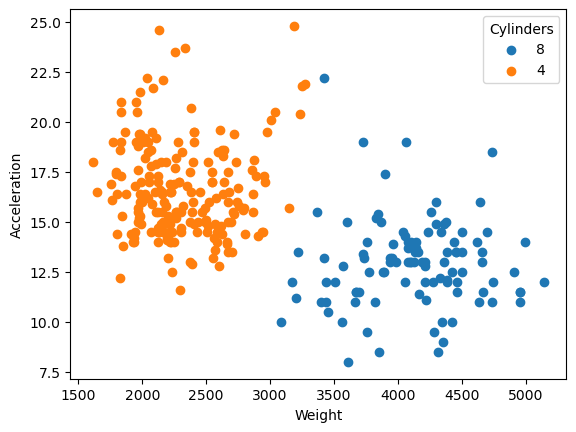

In [15]:
# If we call plt.scatter() twice to display two plots
# To display all plots simultaneously we include plt.show() at the very end.
# The idea is that the graphs are stacked on top of each other

df_8 = carfeatures.query("cylinders == 8")
df_4 = carfeatures.query("cylinders == 4")

plt.scatter(x = df_8["weight"],y = df_8["acceleration"])
plt.scatter(x = df_4["weight"],y = df_4["acceleration"])
plt.legend(labels = ["8","4"],
           title  = "Cylinders")

plt.xlabel("Weight")
plt.ylabel("Acceleration")
plt.show()

# Note: If we put plt.show() in between the plots, then the results will
# be shown on separate graphs instead.

<font size = "4">

Compute plots by all categories

In [ ]:
# Compute number of unique categories
list_unique_cylinders = pd.unique(carfeatures["cylinders"])

# Use a for loop to plot a scatter plot between "weight" and "acceleration"
# for each category. Each plot  will have a different color

for category in list_unique_cylinders:
    df   = carfeatures.query("cylinders == @category")
    plt.scatter(x = df["weight"], y = df["acceleration"])
    
# Add labels and a legends    
plt.xlabel("Weight")
plt.ylabel("Acceleration")
plt.legend(labels = list_unique_cylinders,
           title  = "Cylinders")
plt.show()

<font size="4">

**Exercise:** Compute a histogram of "mpg" by cylinder count for cars with 4, 6, and 8 cylinders.Here is what it might look like (using a fake dataset):

<img src="data/fake_histogram.png" alt="drawing" width="400"/>


You can make the histograms transparent by adjusting ```alpha``` in

```python
    plt.hist(x = ..., alpha = 0.5)
```

In [ ]:
# your code here

